# DeepGlobe U-Net — Results Analysis

Post-training analysis of the best checkpoint: class distribution, confusion matrix, per-class failure modes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

TILES_DIR   = Path('data/deepglobe/tiles_2m')
N_CLASSES   = 6
CLASS_NAMES = ['Urban', 'Agriculture_Rangeland', 'Forest', 'Water', 'Barren', 'Unknown']
CLASS_MAP   = {
    'Urban':                 (0,   255, 255),
    'Agriculture_Rangeland': (255, 255, 0),
    'Forest':                (0,   255, 0),
    'Water':                 (0,   0,   255),
    'Barren':                (255, 255, 255),
    'Unknown':               (0,   0,   0),
}
LABEL_TO_RGB = np.array(list(CLASS_MAP.values()), dtype=np.uint8)

# Tiles on disk keep the original 7-class DeepGlobe labels; Agriculture (1)
# and Rangeland (2) are merged into one class at load time (same as training).
LABEL_REMAP = np.array([0, 1, 1, 2, 3, 4, 5], dtype=np.int32)

## Class Distribution — Pre-Merge (7 classes)

Distribution over the original DeepGlobe taxonomy, before `LABEL_REMAP` folds Agriculture (1)
and Rangeland (2) into a single class. Motivates the merge: Rangeland is a small minority
against an Agriculture class ~7x its size, so ambiguous pixels are biased toward Agriculture.

In [ ]:
RAW_CLASS_NAMES = ['Urban', 'Agriculture', 'Rangeland', 'Forest', 'Water', 'Barren', 'Unknown']
N_RAW = len(RAW_CLASS_NAMES)


def count_raw_class_pixels(split):
    """Pixel counts over the on-disk 7-class labels — no LABEL_REMAP applied."""
    mask_files = sorted((TILES_DIR / split).glob('*_mask.npy'))
    counts = np.zeros(N_RAW, dtype=np.int64)
    for p in mask_files:
        counts += np.bincount(np.load(p).ravel(), minlength=N_RAW)
    return counts, len(mask_files)


raw_train_counts, _ = count_raw_class_pixels('train')
raw_val_counts,   _ = count_raw_class_pixels('val')
raw_all_counts      = raw_train_counts + raw_val_counts

raw_train_freq = raw_train_counts / raw_train_counts.sum()
raw_val_freq   = raw_val_counts   / raw_val_counts.sum()
raw_all_freq   = raw_all_counts   / raw_all_counts.sum()

print(f'{"Class":<14} {"Train %":>9} {"Val %":>9} {"All %":>9} {"All px":>14}')
print('-' * 58)
for i, name in enumerate(RAW_CLASS_NAMES):
    print(f'{name:<14} {raw_train_freq[i]*100:>8.2f}% {raw_val_freq[i]*100:>8.2f}%'
          f' {raw_all_freq[i]*100:>8.2f}% {raw_all_counts[i]:>14,}')

agri, rang = raw_all_counts[1], raw_all_counts[2]
print(f'\nAgriculture / Rangeland ratio: {agri / rang:.2f}x')
print(f'Merged class share: {(agri + rang) / raw_all_counts.sum() * 100:.2f}%'
      f'  (Agriculture {agri / (agri + rang) * 100:.1f}%,'
      f' Rangeland {rang / (agri + rang) * 100:.1f}% of it)')


Class            Train %     Val %     All %         All px
----------------------------------------------------------
Urban             10.93%    10.07%    10.80%     51,158,448
Agriculture       58.15%    55.70%    57.79%    273,696,111
Rangeland          8.70%     7.11%     8.46%     40,066,933
Forest            11.53%     8.85%    11.13%     52,697,149
Water              3.26%     3.74%     3.33%     15,773,656
Barren             7.38%    14.53%     8.45%     40,011,179
Unknown            0.06%     0.00%     0.05%        225,196

Agriculture / Rangeland ratio: 6.83x
Merged class share: 66.25%  (Agriculture 87.2%, Rangeland 12.8% of it)


## Pre-Merge Confusion Matrix (7 classes)

Confusion matrix of the last 7-class checkpoint, before Agriculture and Rangeland were
merged. This is the quantitative evidence behind the merge: Rangeland is largely absorbed
by Agriculture, the majority class it is visually closest to at 2 m.

Uses `RAW_CLASS_NAMES` from the pre-merge distribution cell and loads its own model, so it
does not disturb the 6-class `model` / `cm` variables used by the cells above.


Loaded: best-20260702-downsample-overlap-color-aug-dropout-30-batch-32-lr-1e-4-miou-63.keras

Class            Recall      IoU   Support (px)
------------------------------------------------
Urban            0.8571   0.7529      7,127,151
Agriculture      0.9345   0.8754     39,423,926
Rangeland        0.6353   0.4541      5,032,542
Forest           0.9148   0.8357      6,261,755
Water            0.8839   0.8244      2,649,695
Barren           0.8317   0.7213     10,283,041
Unknown          0.0000   0.0000            770

Rangeland -> Agriculture: 20.1% of true Rangeland px
Agriculture -> Rangeland: 2.8% of true Agriculture px


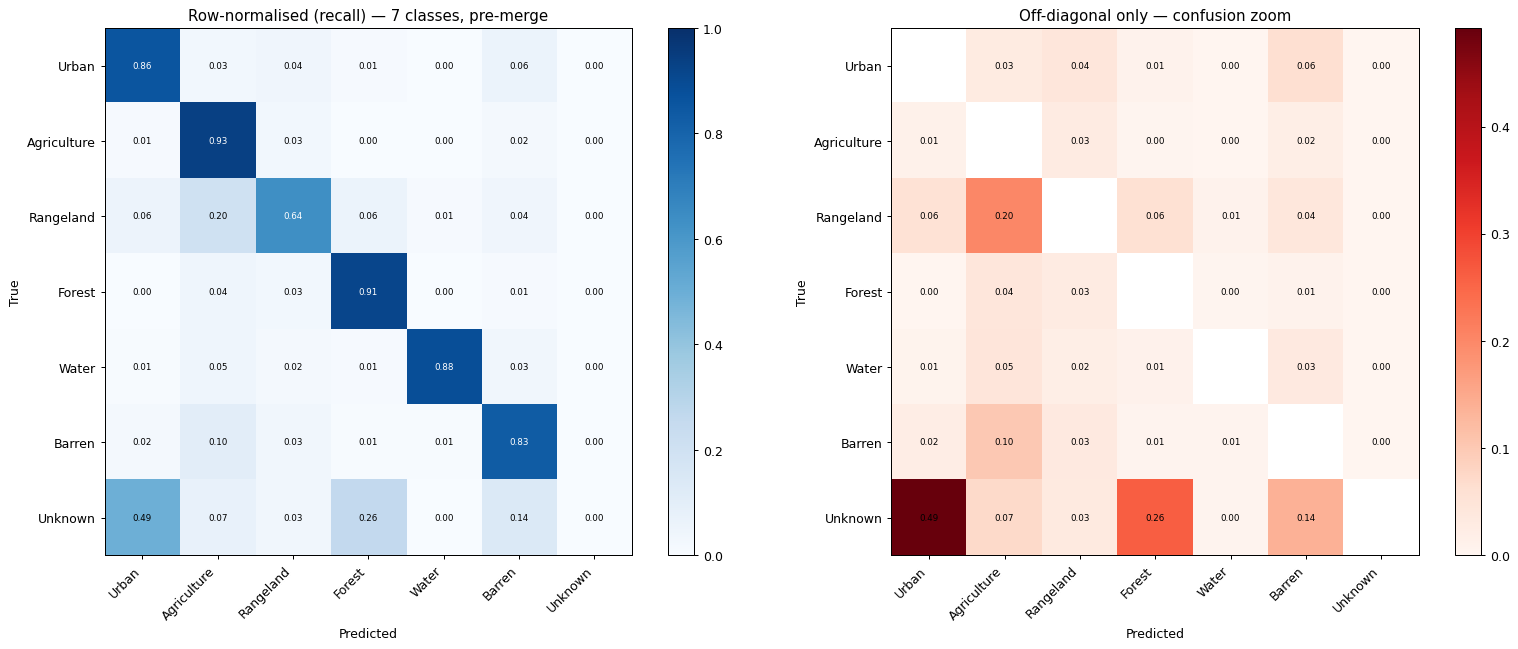

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

PRE_MERGE_PATH = Path('models/deepglobe_unet/'
                      'best-20260702-downsample-overlap-color-aug-dropout-30-'
                      'batch-32-lr-1e-4-miou-63.keras')

RAW_CLASS_MAP = {
    'Urban':       (0,   255, 255),
    'Agriculture': (255, 255, 0),
    'Rangeland':   (255, 0,   255),
    'Forest':      (0,   255, 0),
    'Water':       (0,   0,   255),
    'Barren':      (255, 255, 255),
    'Unknown':     (0,   0,   0),
}


def dice_loss_raw(y_true, y_pred, smooth=1e-6):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), N_RAW)
    axes = [1, 2]
    intersection = tf.reduce_sum(y_true_oh * y_pred, axis=axes)
    union = tf.reduce_sum(y_true_oh, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
    return 1.0 - tf.reduce_mean((2.0 * intersection + smooth) / (union + smooth))


def bce_dice_loss_raw(y_true, y_pred):
    return tf.keras.losses.SparseCategoricalCrossentropy()(y_true, y_pred) + dice_loss_raw(y_true, y_pred)


model_raw = tf.keras.models.load_model(
    str(PRE_MERGE_PATH),
    custom_objects={'bce_dice_loss': bce_dice_loss_raw, 'dice_loss': dice_loss_raw},
)
assert model_raw.output_shape[-1] == N_RAW, model_raw.output_shape
print(f'Loaded: {PRE_MERGE_PATH.name}')

# ── Val set with the original 7-class labels (no LABEL_REMAP) ─────────────────
d = TILES_DIR / 'val'
cm_raw = np.zeros((N_RAW, N_RAW), dtype=np.int64)

for sat_path in sorted(d.glob('*_sat.npy')):
    mask_path = d / sat_path.name.replace('_sat.npy', '_mask.npy')
    img = np.load(sat_path).astype(np.uint8)
    label = np.load(mask_path).astype(np.int32)
    pred = model_raw(tf.expand_dims(tf.cast(img, tf.uint8), 0), training=False)[0]
    pred_cls = tf.argmax(pred, axis=-1).numpy()
    cm_raw += np.bincount(
        (label.ravel() * N_RAW + pred_cls.ravel()), minlength=N_RAW * N_RAW
    ).reshape(N_RAW, N_RAW)

cm_raw_recall = cm_raw.astype(np.float64) / cm_raw.sum(axis=1, keepdims=True).clip(1)

# ── Per-class IoU from the confusion matrix ───────────────────────────────────
tp = np.diag(cm_raw).astype(np.float64)
iou_raw = tp / (cm_raw.sum(axis=1) + cm_raw.sum(axis=0) - tp).clip(1)

print(f'\n{"Class":<14} {"Recall":>8} {"IoU":>8} {"Support (px)":>14}')
print('-' * 48)
for i, name in enumerate(RAW_CLASS_NAMES):
    print(f'{name:<14} {cm_raw_recall[i, i]:>8.4f} {iou_raw[i]:>8.4f} {cm_raw.sum(axis=1)[i]:>14,}')

rng_i, agr_i = RAW_CLASS_NAMES.index('Rangeland'), RAW_CLASS_NAMES.index('Agriculture')
print(f'\nRangeland -> Agriculture: {cm_raw_recall[rng_i, agr_i]*100:.1f}% of true Rangeland px')
print(f'Agriculture -> Rangeland: {cm_raw_recall[agr_i, rng_i]*100:.1f}% of true Agriculture px')

# ── Plot ─────────────────────────────────────────────────────────────────────
cm_raw_off = cm_raw_recall.copy()
np.fill_diagonal(cm_raw_off, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
im0 = axes[0].imshow(cm_raw_recall, cmap='Blues', vmin=0, vmax=1)
im1 = axes[1].imshow(cm_raw_off, cmap='Reds')
axes[0].set_title('Row-normalised (recall) — 7 classes, pre-merge')
axes[1].set_title('Off-diagonal only — confusion zoom')
plt.colorbar(im0, ax=axes[0])
plt.colorbar(im1, ax=axes[1])

for ax, data in ((axes[0], cm_raw_recall), (axes[1], cm_raw_off)):
    ax.set_xticks(range(N_RAW)); ax.set_yticks(range(N_RAW))
    ax.set_xticklabels(RAW_CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticklabels(RAW_CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(N_RAW):
        for j in range(N_RAW):
            v = data[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if v > 0.55 else 'black')

plt.tight_layout()
plt.show()


## Class Distribution

Pixel-level frequency of each class across train and val tile sets.

Train tiles: 6147  |  Val tiles: 1080

Class                      Train px  Train %       Val px    Val %
------------------------------------------------------------------
Urban                    44,031,297   10.93%    7,127,151   10.07%
Agriculture_Rangeland   269,306,576   66.85%   44,456,468   62.81%
Forest                   46,435,394   11.53%    6,261,755    8.85%
Water                    13,123,961    3.26%    2,649,695    3.74%
Barren                   29,728,138    7.38%   10,283,041   14.53%
Unknown                     224,426    0.06%          770    0.00%


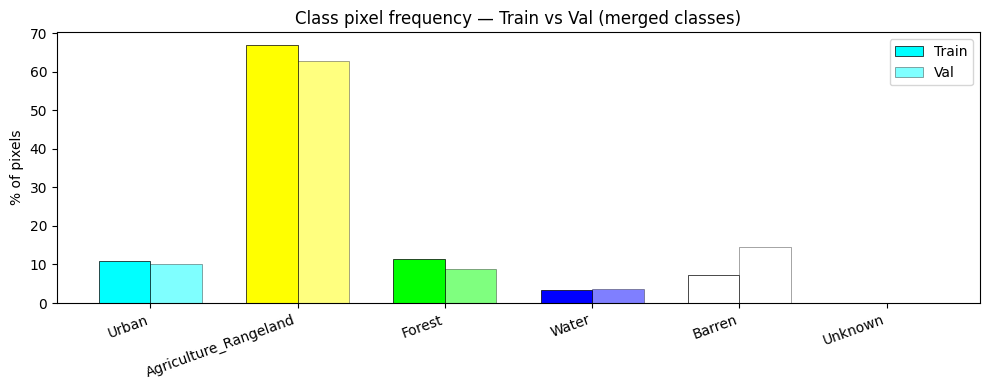

In [2]:
def count_class_pixels(split):
    mask_files = sorted((TILES_DIR / split).glob('*_mask.npy'))
    counts = np.zeros(N_CLASSES, dtype=np.int64)
    for p in mask_files:
        counts += np.bincount(LABEL_REMAP[np.load(p)].ravel(), minlength=N_CLASSES)
    return counts, len(mask_files)

train_counts, n_train = count_class_pixels('train')
val_counts,   n_val   = count_class_pixels('val')

train_freq = train_counts / train_counts.sum()
val_freq   = val_counts   / val_counts.sum()

print(f'Train tiles: {n_train}  |  Val tiles: {n_val}\n')
print(f'{"Class":<22} {"Train px":>12} {"Train %":>8} {"Val px":>12} {"Val %":>8}')
print('-' * 66)
for i, name in enumerate(CLASS_NAMES):
    print(f'{name:<22} {train_counts[i]:>12,} {train_freq[i]*100:>7.2f}%'
          f' {val_counts[i]:>12,} {val_freq[i]*100:>7.2f}%')

# ── Plot ──────────────────────────────────────────────────────────────────────
x = np.arange(N_CLASSES)
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, train_freq * 100, w, label='Train',
       color=[np.array(c)/255 for c in CLASS_MAP.values()], edgecolor='k', linewidth=0.5)
ax.bar(x + w/2, val_freq   * 100, w, label='Val',
       color=[np.array(c)/255 for c in CLASS_MAP.values()], edgecolor='k', linewidth=0.5,
       alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.set_ylabel('% of pixels')
ax.set_title('Class pixel frequency — Train vs Val (merged classes)')
ax.legend()
plt.tight_layout()
plt.show()

## Model Evaluation

Load best checkpoint and re-run metrics on the val set.

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)
print('GPUs:', tf.config.list_physical_devices('GPU'))

BATCH_SIZE  = 8
TILE_SIZE   = 256
MODEL_PATH  = Path('models/deepglobe_unet/best-20260702-downsample-overlap-color-aug-dropout-30-merged-class-batch-32-lr-1e-4-miou-67.keras')

# ── Loss (required for model.load) ────────────────────────────────────────────
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), N_CLASSES)
    axes = [1, 2]
    intersection   = tf.reduce_sum(y_true_oh * y_pred, axis=axes)
    union          = tf.reduce_sum(y_true_oh, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - tf.reduce_mean(dice_per_class)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.SparseCategoricalCrossentropy()(y_true, y_pred) + dice_loss(y_true, y_pred)

model = tf.keras.models.load_model(
    str(MODEL_PATH),
    custom_objects={'bce_dice_loss': bce_dice_loss, 'dice_loss': dice_loss},
)
print(f'Loaded: {MODEL_PATH.name}')
assert model.output_shape[-1] == N_CLASSES, f'Model outputs {model.output_shape[-1]} classes, expected {N_CLASSES}'

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loaded: best-20260702-downsample-overlap-color-aug-dropout-30-merged-class-batch-32-lr-1e-4-miou-67.keras


In [ ]:
# ── tf.data pipeline (no augmentation, eval only) ────────────────────────────
def _load(sat_path, mask_path):
    img   = np.load(sat_path.numpy().decode()).astype(np.uint8)
    label = LABEL_REMAP[np.load(mask_path.numpy().decode())]
    return img, label

def tf_load(sat_path, mask_path):
    img, label = tf.py_function(_load, [sat_path, mask_path], [tf.uint8, tf.int32])
    img.set_shape([TILE_SIZE, TILE_SIZE, 3])
    label.set_shape([TILE_SIZE, TILE_SIZE])
    return img, label

def make_eval_ds(split, batch_size=BATCH_SIZE):
    d = TILES_DIR / split
    sat_files = sorted(d.glob('*_sat.npy'))
    sat_p  = [str(p) for p in sat_files]
    mask_p = [str(d / p.name.replace('_sat.npy', '_mask.npy')) for p in sat_files]
    ds = (
        tf.data.Dataset.from_tensor_slices((sat_p, mask_p))
        .map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    print(f'{split}: {len(sat_files)} tiles, {len(ds)} batches')
    return ds

train_ds = make_eval_ds('train')
val_ds   = make_eval_ds('val')

train: 6147 tiles, 769 batches
val: 1080 tiles, 135 batches


In [ ]:
def build_metrics():
    return [
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.MeanIoU(num_classes=N_CLASSES, name='miou', sparse_y_pred=False),
        *[
            tf.keras.metrics.IoU(
                num_classes=N_CLASSES, target_class_ids=[i],
                name=f'iou_{CLASS_NAMES[i].lower()}', sparse_y_pred=False,
            )
            for i in range(N_CLASSES)
        ],
    ]

METRIC_NAMES = ['loss', 'accuracy', 'miou'] + [f'iou_{n.lower()}' for n in CLASS_NAMES]

# Merged-class run (overlap grid + freeze warmup) — fill from the wandb run
# summary of best-20260702-...-merged-class-...-miou-67. NaN = not filled yet.
PREVIOUS_TRAIN = {k: float('nan') for k in METRIC_NAMES}
PREVIOUS_VAL   = {k: float('nan') for k in METRIC_NAMES}
PREVIOUS_VAL['miou'] = 0.67  # from checkpoint filename

results = {}
for split, ds, reported in (('train', train_ds, PREVIOUS_TRAIN), ('val', val_ds, PREVIOUS_VAL)):
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=bce_dice_loss, metrics=build_metrics())
    r = model.evaluate(ds, verbose=1)
    results[split] = dict(zip(METRIC_NAMES, r))
    print(f'\n── {split} ──')
    print(f'{"Metric":<28} {"Computed":>10} {"Reported":>10} {"Δ":>8}')
    print('-' * 60)
    for k in METRIC_NAMES:
        c = results[split][k]
        rep = reported.get(k, float('nan'))
        print(f'{k:<28} {c:>10.4f} {rep:>10.4f} {c-rep:>+8.4f}')

769/769 ━━━━━━━━━━━━━━━━━━━━ 153s 120ms/step - accuracy: 0.9615 - iou_agriculture_rangeland: 0.9539 - iou_barren: 0.8595 - iou_forest: 0.9144 - iou_unknown: 0.4252 - iou_urban: 0.8424 - iou_water: 0.8607 - loss: 0.8430 - miou: 0.8093

── train ──
Metric                         Computed   Reported        Δ
------------------------------------------------------------
loss                             0.8430        nan     +nan
accuracy                         0.9615        nan     +nan
miou                             0.8093        nan     +nan
iou_urban                        0.8424        nan     +nan
iou_agriculture_rangeland        0.9539        nan     +nan
iou_forest                       0.9144        nan     +nan
iou_water                        0.8607        nan     +nan
iou_barren                       0.8595        nan     +nan
iou_unknown                      0.4252        nan     +nan
135/135 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.9204 - iou_agriculture_rangeland: 0

## Confusion Matrix

Pixel-level confusion matrix on val set. Row = true class, column = predicted class.
Row-normalized → recall per class. Reveals what each class gets confused with.


Class            Recall  Precision       F1   Support (px)
----------------------------------------------------------
Urban            0.8533     0.8782   0.8655      7,127,151
Agriculture_Rangeland   0.9544     0.9421   0.9482     44,456,468
Forest           0.8886     0.9075   0.8979      6,261,755
Water            0.8965     0.9328   0.9143      2,649,695
Barren           0.8453     0.8575   0.8514     10,283,041
Unknown          0.0000     0.0000   0.0000            770

Top 10 off-diagonal confusions (true → predicted, % of true class pixels):
  Unknown        → Urban            45.3%
  Unknown        → Forest           31.4%
  Unknown        → Agriculture_Rangeland   13.5%
  Barren         → Agriculture_Rangeland   12.4%
  Forest         → Agriculture_Rangeland    9.7%
  Unknown        → Barren            9.4%
  Urban          → Agriculture_Rangeland    7.8%
  Water          → Agriculture_Rangeland    6.6%
  Urban          → Barren            5.8%
  Water          → Barren      

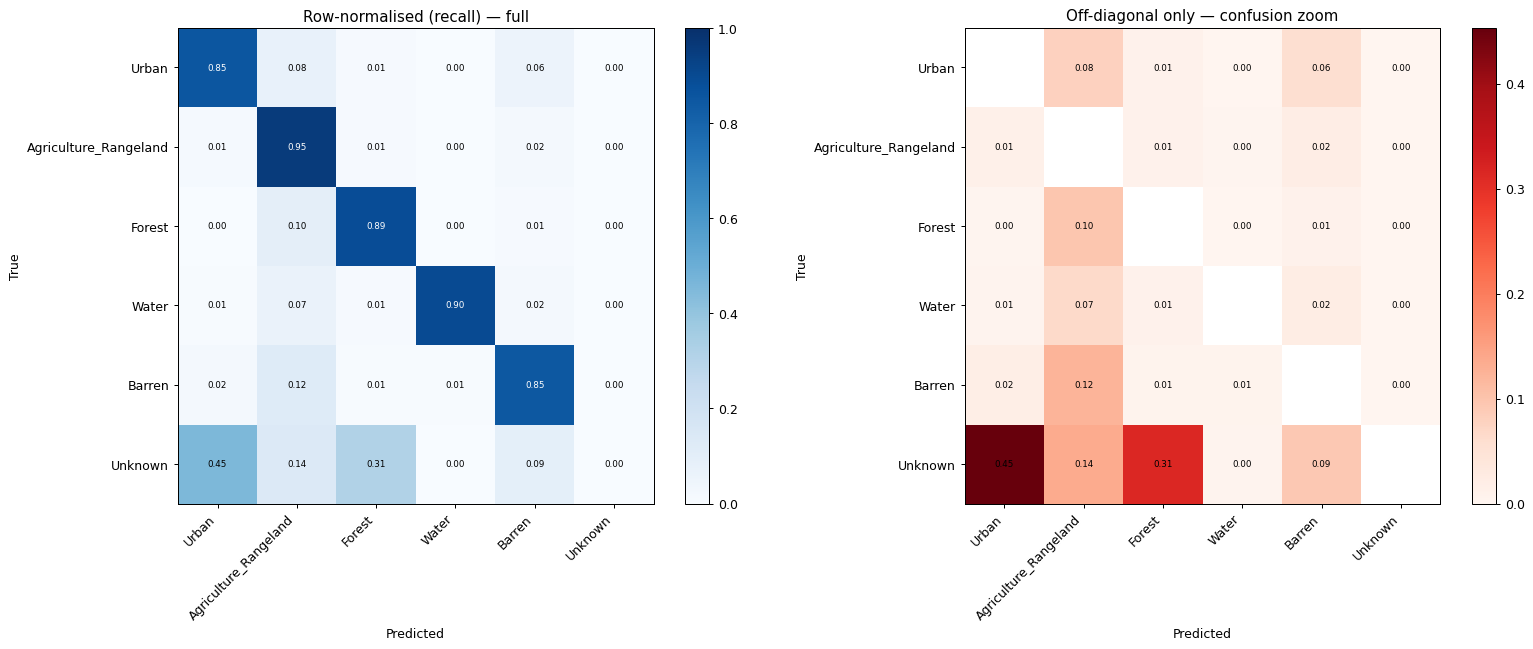

In [ ]:
# Accumulate confusion matrix batch-by-batch (avoids holding all predictions in memory)
cm = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)

for imgs, labels in val_ds:
    preds    = model(imgs, training=False)          # (B, H, W, C) softmax
    pred_cls = tf.argmax(preds, axis=-1)            # (B, H, W)
    batch_cm = tf.math.confusion_matrix(
        tf.reshape(labels, [-1]),
        tf.reshape(pred_cls, [-1]),
        num_classes=N_CLASSES,
    )
    cm += batch_cm.numpy()

# ── Row-normalised (recall view) ──────────────────────────────────────────────
cm_recall = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True).clip(1)

# Off-diagonal: mask diagonal so colormap autoscales to confusion range
cm_offdiag = cm_recall.copy()
np.fill_diagonal(cm_offdiag, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

im0 = axes[0].imshow(cm_recall,   cmap='Blues', vmin=0, vmax=1)
im1 = axes[1].imshow(cm_offdiag,  cmap='Reds')

axes[0].set_title('Row-normalised (recall) — full')
axes[1].set_title('Off-diagonal only — confusion zoom')
plt.colorbar(im0, ax=axes[0])
plt.colorbar(im1, ax=axes[1])

for ax, data in ((axes[0], cm_recall), (axes[1], cm_offdiag)):
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            v = data[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if v > 0.55 else 'black')

plt.tight_layout()
plt.show()

# ── Per-class precision / recall / F1 ─────────────────────────────────────────
print(f'\n{"Class":<14} {"Recall":>8} {"Precision":>10} {"F1":>8} {"Support (px)":>14}')
print('-' * 58)
for i, name in enumerate(CLASS_NAMES):
    tp        = cm[i, i]
    recall    = tp / cm[i].sum().clip(1)
    precision = tp / cm[:, i].sum().clip(1)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    print(f'{name:<14} {recall:>8.4f} {precision:>10.4f} {f1:>8.4f} {cm[i].sum():>14,}')

# ── Top confusions (off-diagonal) ─────────────────────────────────────────────
print('\nTop 10 off-diagonal confusions (true → predicted, % of true class pixels):')
off = [(cm_recall[i, j], CLASS_NAMES[i], CLASS_NAMES[j])
       for i in range(N_CLASSES) for j in range(N_CLASSES) if i != j]
for rate, true_cls, pred_cls in sorted(off, reverse=True)[:10]:
    print(f'  {true_cls:<14} → {pred_cls:<14}  {rate*100:5.1f}%')

## Merged-Class Tile Visualization

With Agriculture and Rangeland merged, the old Rangeland↔Agriculture confusion no longer exists.
This section inspects the merged Agriculture_Rangeland class: tiles where it is correctly recalled
vs tiles where it leaks into its top confuser (computed from the confusion matrix above).
Only tiles with ≥5% merged-class pixels included.

Top confuser for Agriculture_Rangeland: Barren (2.0% of true px)
Tiles with ≥5% Agriculture_Rangeland: 876


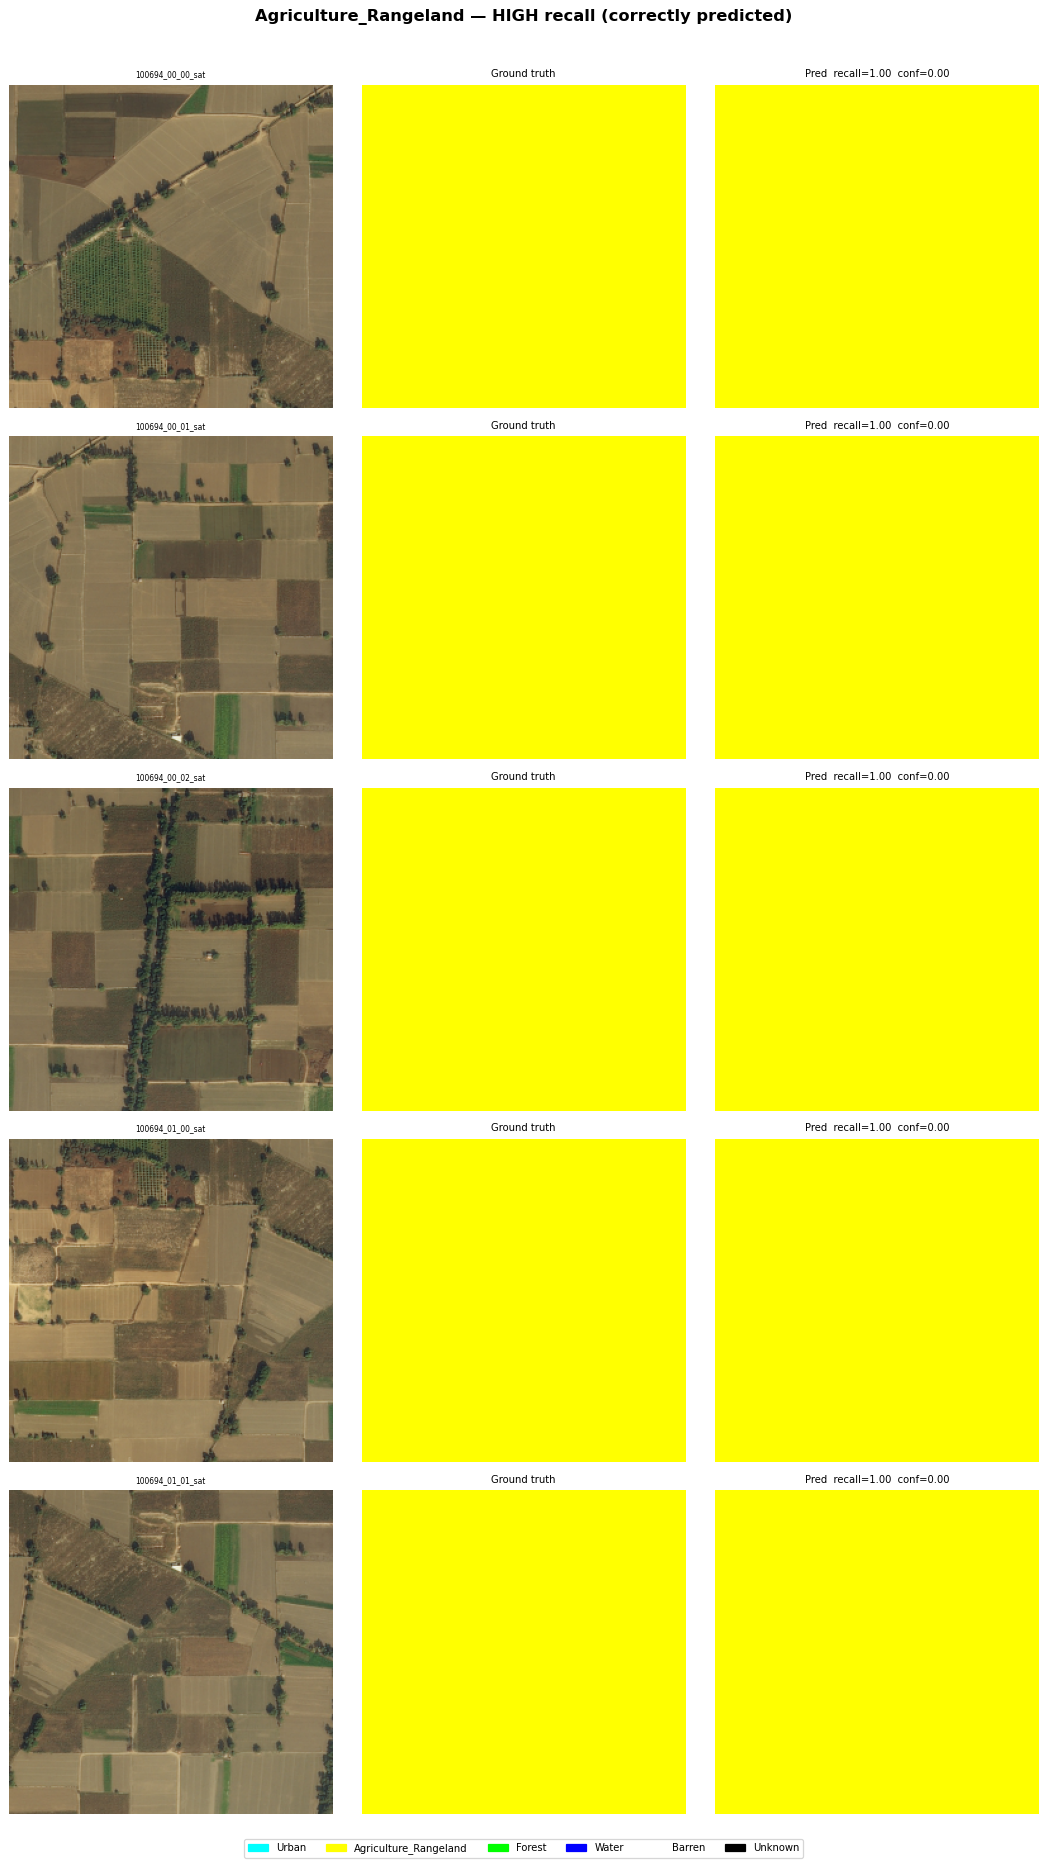

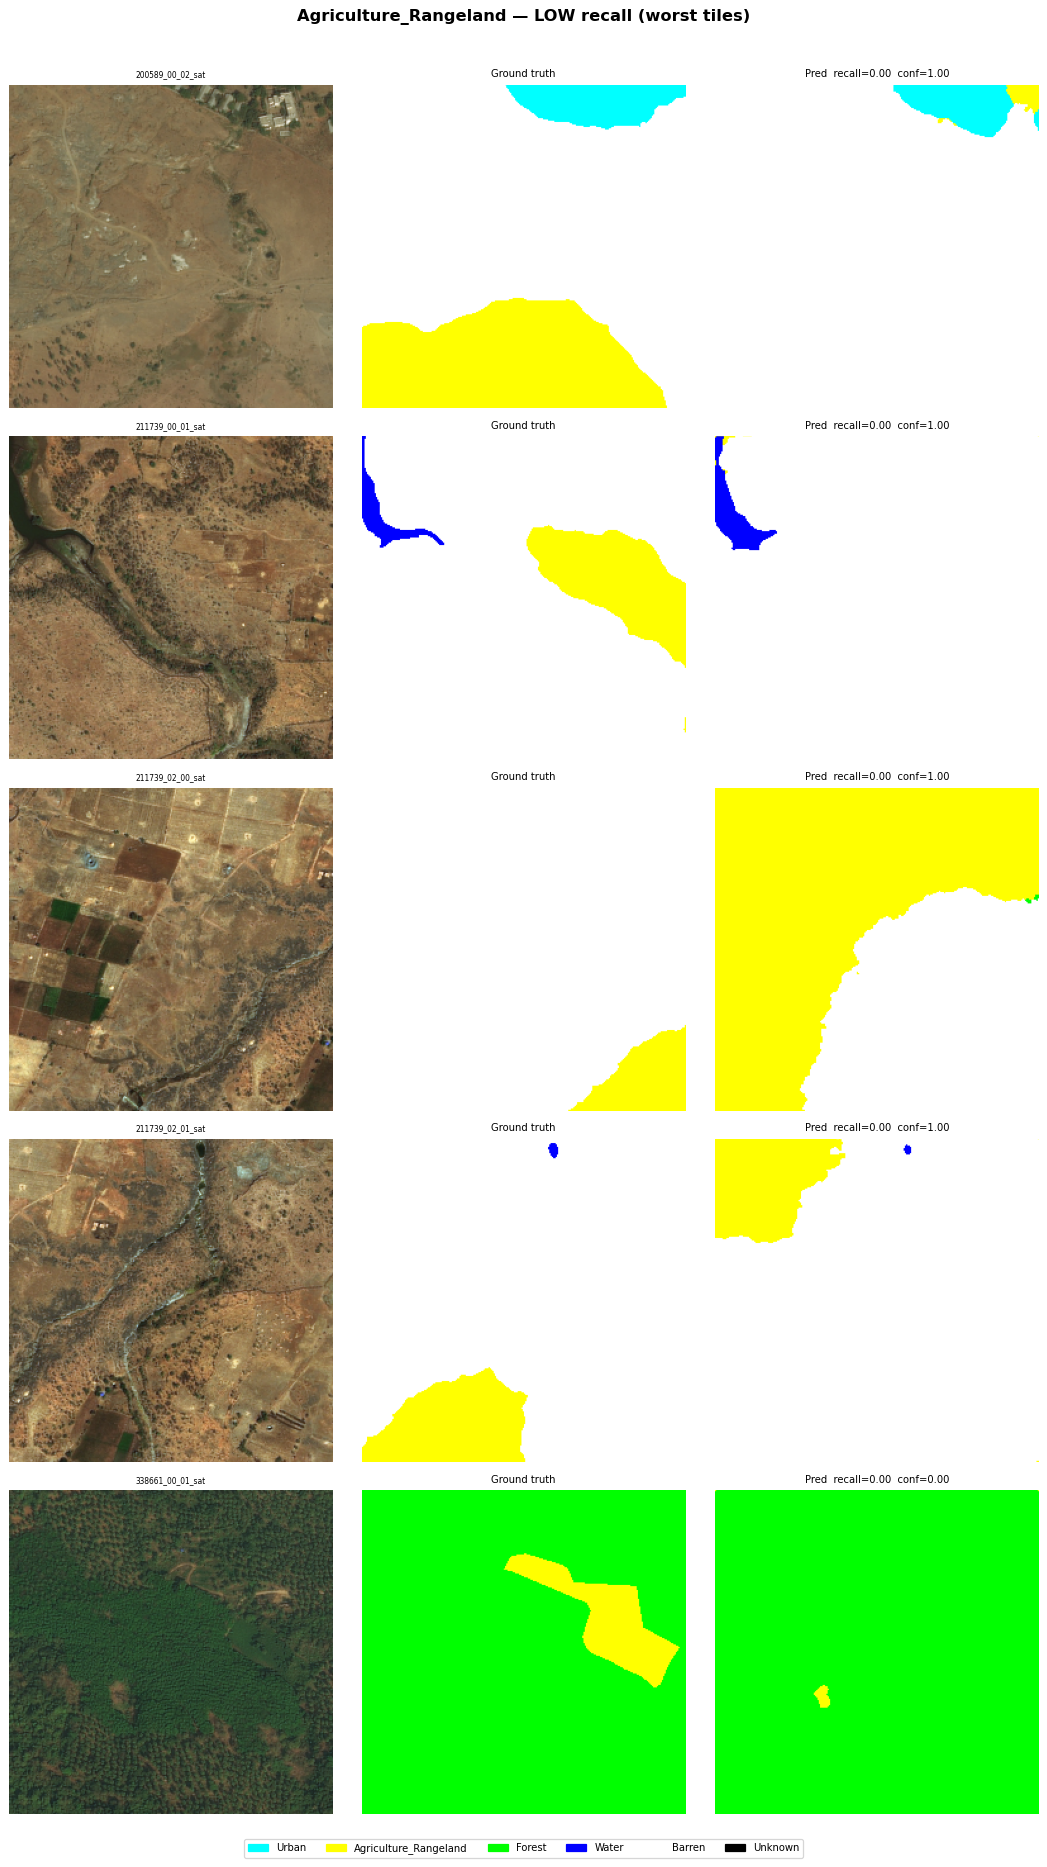

In [ ]:
TARGET_IDX = CLASS_NAMES.index('Agriculture_Rangeland')

# Top confuser for the target class, from the val confusion matrix
conf_row = cm_recall[TARGET_IDX].copy()
conf_row[TARGET_IDX] = 0
CONFUSER_IDX = int(np.argmax(conf_row))
print(f'Top confuser for {CLASS_NAMES[TARGET_IDX]}: '
      f'{CLASS_NAMES[CONFUSER_IDX]} ({conf_row[CONFUSER_IDX]*100:.1f}% of true px)')

MIN_TARGET_PX = int(TILE_SIZE * TILE_SIZE * 0.05)  # ≥5% of tile

# ── Score each val tile ────────────────────────────────────────────────────────
tile_stats = []  # (sat_path, img, label, pred_cls, recall, conf_rate)
d = TILES_DIR / 'val'

for sat_path in sorted(d.glob('*_sat.npy')):
    mask_path = d / sat_path.name.replace('_sat.npy', '_mask.npy')
    img   = np.load(sat_path).astype(np.uint8)
    label = LABEL_REMAP[np.load(mask_path)]

    n_target = int((label == TARGET_IDX).sum())
    if n_target < MIN_TARGET_PX:
        continue

    pred     = model(tf.expand_dims(tf.cast(img, tf.uint8), 0), training=False)[0]
    pred_cls = tf.argmax(pred, axis=-1).numpy()

    target_mask = (label == TARGET_IDX)
    recall    = float((pred_cls == TARGET_IDX)[target_mask].sum()) / n_target
    conf_rate = float((pred_cls == CONFUSER_IDX)[target_mask].sum()) / n_target

    tile_stats.append((str(sat_path), img, label, pred_cls, recall, conf_rate))

print(f'Tiles with ≥5% {CLASS_NAMES[TARGET_IDX]}: {len(tile_stats)}')

# ── Legend patches ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=np.array(c)/255, label=n)
    for n, c in CLASS_MAP.items()
]

# ── Plot helper ────────────────────────────────────────────────────────────────
def show_target_tiles(tiles, suptitle, n_show=5):
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
    fig.suptitle(suptitle, fontsize=13, fontweight='bold', y=1.01)
    for row, (path, img, label, pred_cls, recall, conf_rate) in enumerate(tiles[:n_show]):
        ax_img, ax_gt, ax_pr = axes[row]
        ax_img.imshow(img)
        ax_img.set_title(Path(path).stem, fontsize=6)
        ax_img.axis('off')

        ax_gt.imshow(LABEL_TO_RGB[label])
        ax_gt.set_title('Ground truth', fontsize=8)
        ax_gt.axis('off')

        ax_pr.imshow(LABEL_TO_RGB[pred_cls])
        ax_pr.set_title(f'Pred  recall={recall:.2f}  conf={conf_rate:.2f}', fontsize=8)
        ax_pr.axis('off')

    fig.legend(handles=legend_patches, loc='lower center', ncol=len(CLASS_NAMES),
               bbox_to_anchor=(0.5, -0.02), fontsize=8)
    plt.tight_layout()
    plt.show()

# ── High recall (model gets merged class right) ────────────────────────────────
good = sorted(tile_stats, key=lambda x: x[4], reverse=True)
show_target_tiles(good, f'{CLASS_NAMES[TARGET_IDX]} — HIGH recall (correctly predicted)')

# ── Worst recall (where merged class is lost) ──────────────────────────────────
bad = sorted(tile_stats, key=lambda x: x[4])
show_target_tiles(bad, f'{CLASS_NAMES[TARGET_IDX]} — LOW recall (worst tiles)')

## Random Val Tiles

10 randomly selected val tiles: image, ground truth, prediction — unbiased sample of overall prediction quality.

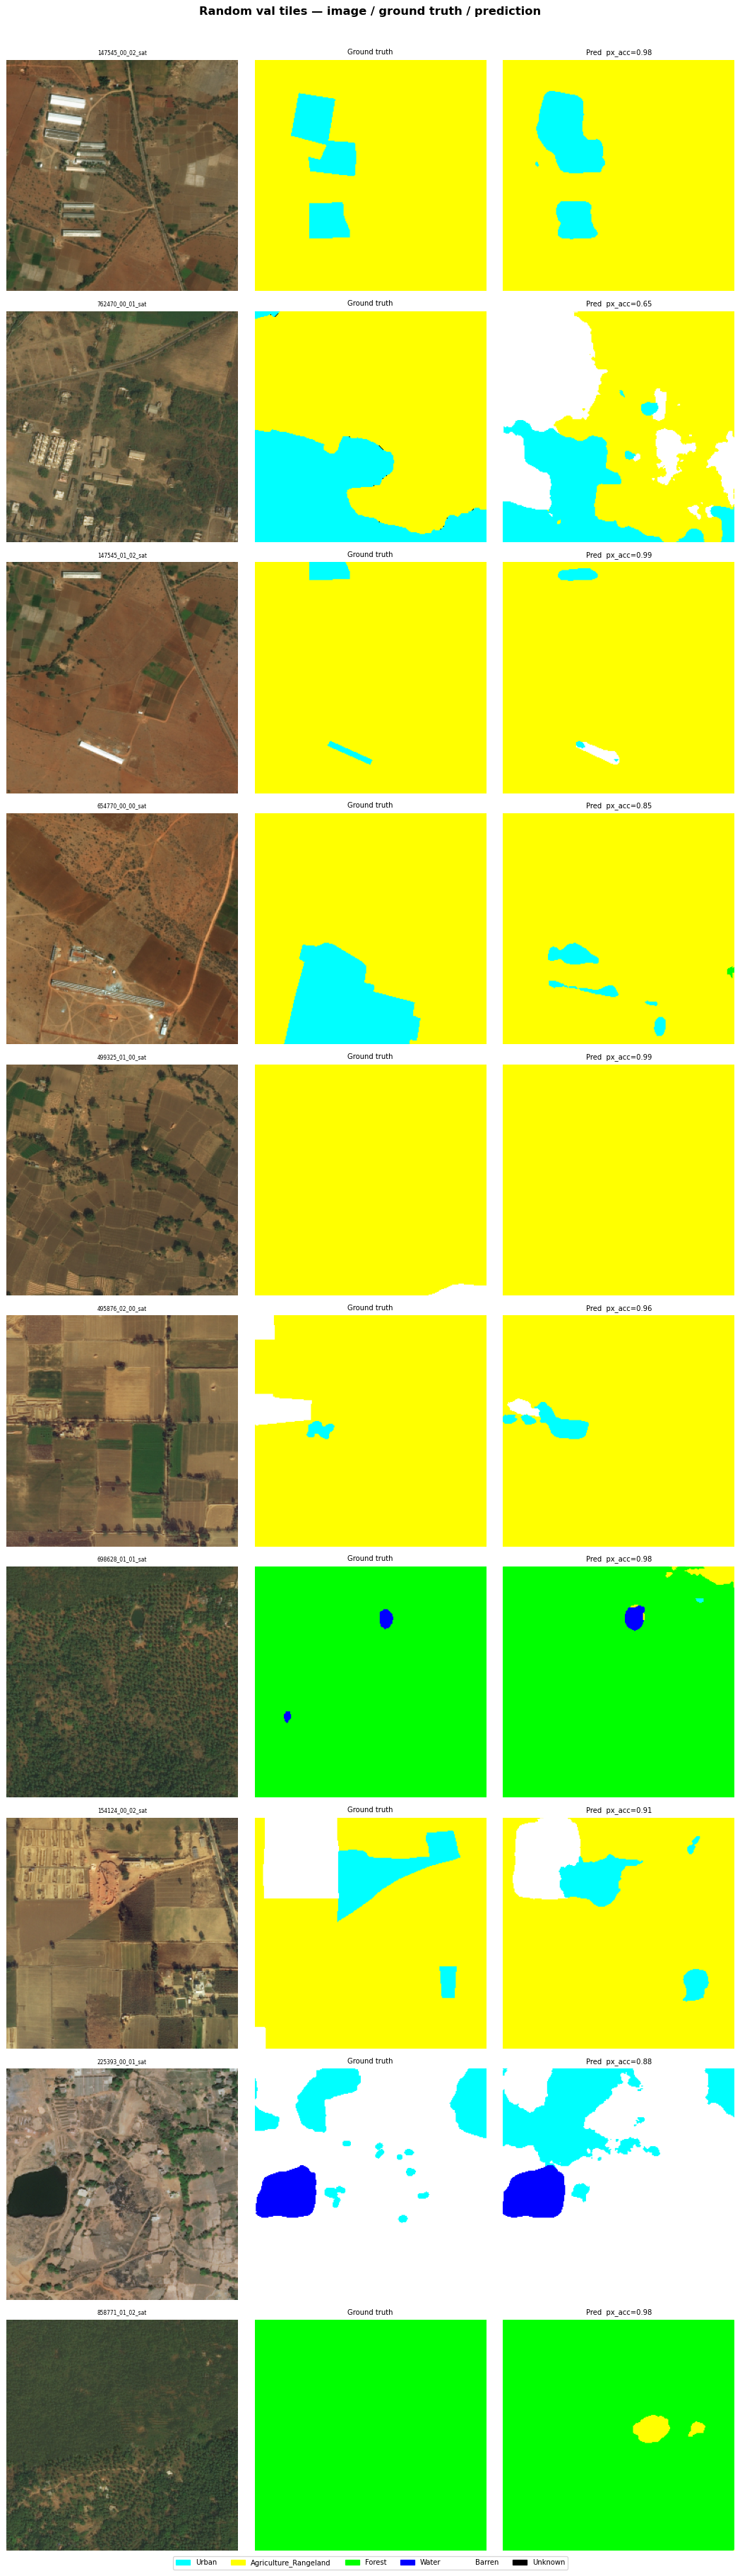

In [ ]:
N_SAMPLES = 10
rng = np.random.default_rng(42)

d = TILES_DIR / 'val'
all_sats = sorted(d.glob('*_sat.npy'))
sample   = [all_sats[i] for i in rng.choice(len(all_sats), N_SAMPLES, replace=False)]

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))
fig.suptitle('Random val tiles — image / ground truth / prediction',
             fontsize=13, fontweight='bold', y=1.005)

for row, sat_path in enumerate(sample):
    mask_path = d / sat_path.name.replace('_sat.npy', '_mask.npy')
    img   = np.load(sat_path).astype(np.uint8)
    label = LABEL_REMAP[np.load(mask_path)]

    pred     = model(tf.expand_dims(tf.cast(img, tf.uint8), 0), training=False)[0]
    pred_cls = tf.argmax(pred, axis=-1).numpy()

    acc = float((pred_cls == label).mean())

    ax_img, ax_gt, ax_pr = axes[row]
    ax_img.imshow(img)
    ax_img.set_title(sat_path.stem, fontsize=6)
    ax_img.axis('off')

    ax_gt.imshow(LABEL_TO_RGB[label])
    ax_gt.set_title('Ground truth', fontsize=8)
    ax_gt.axis('off')

    ax_pr.imshow(LABEL_TO_RGB[pred_cls])
    ax_pr.set_title(f'Pred  px_acc={acc:.2f}', fontsize=8)
    ax_pr.axis('off')

fig.legend(handles=legend_patches, loc='lower center', ncol=len(CLASS_NAMES),
           bbox_to_anchor=(0.5, -0.005), fontsize=8)
plt.tight_layout()
plt.show()

## Figure Export

Renders the figures referenced by the report to SVG, into the report repository.
Requires the cells above to have run: `cm_recall` (6-class), `cm_raw_recall` (7-class),
`model`, and `tile_stats`.

Confusion matrices are exported as the row-normalised (recall) panel only. The
off-diagonal companion panel used for on-screen inspection is not exported, since the
report discusses the confusions numerically in the text.


In [ ]:
from pathlib import Path

EXPORT_DIR = Path('../PFC_Report/cap5/img')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print('exporting to', EXPORT_DIR.resolve())

for _name in ('cm_recall', 'cm_raw_recall', 'tile_stats', 'model'):
    if _name not in globals():
        raise NameError(f'{_name} is undefined — run the cells above first')


def export_confusion(cm_norm, names, out_name, figsize=(7.5, 6.2)):
    """Row-normalised confusion matrix, single panel, for the report."""
    n = len(names)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Predita', fontsize=10)
    ax.set_ylabel('Verdadeira', fontsize=10)
    for i in range(n):
        for j in range(n):
            v = cm_norm[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if v > 0.55 else 'black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    out = EXPORT_DIR / out_name
    fig.savefig(out, format='svg', bbox_inches='tight')
    plt.close(fig)
    print('wrote', out, f'({out.stat().st_size/1024:.0f} kB)')


export_confusion(cm_recall, CLASS_NAMES, 'cm_final.svg')
export_confusion(cm_raw_recall, RAW_CLASS_NAMES, 'cm_premerge.svg')


exporting to /home/jvpcms/ime/PFC_Report/cap5/img
wrote ../PFC_Report/cap5/img/cm_final.svg (51 kB)
wrote ../PFC_Report/cap5/img/cm_premerge.svg (57 kB)


In [ ]:
EXPORT_DIR = Path('../PFC_Report/cap5/img')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def _panel(ax, arr, title, fontsize=8):
    ax.imshow(arr, interpolation='nearest')
    ax.set_title(title, fontsize=fontsize)
    ax.axis('off')


def export_tile_grid(rows, out_name, row_notes=None, col_titles=('Imagem', 'Referência', 'Predição')):
    """rows: list of (img, label, pred_cls). One figure row per entry."""
    n = len(rows)
    fig, axes = plt.subplots(n, 3, figsize=(8.4, 2.9 * n))
    axes = np.atleast_2d(axes)
    for r, (img, label, pred_cls) in enumerate(rows):
        note = row_notes[r] if row_notes else ''
        _panel(axes[r, 0], img, col_titles[0] if r == 0 else '')
        _panel(axes[r, 1], LABEL_TO_RGB[label], col_titles[1] if r == 0 else '')
        _panel(axes[r, 2], LABEL_TO_RGB[pred_cls], (col_titles[2] if r == 0 else '') + note)
    fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=8,
               bbox_to_anchor=(0.5, -0.01))
    fig.tight_layout()
    out = EXPORT_DIR / out_name
    fig.savefig(out, format='svg', bbox_inches='tight')
    plt.close(fig)
    print('wrote', out, f'({out.stat().st_size/1024:.0f} kB)')


# ── Heterogeneous validation crops ────────────────────────────────────────────
# A uniform random draw is dominated by single-class Agriculture_Rangeland crops
# (66% of val pixels), which show nothing about segmentation quality. Select instead
# by class diversity, and diversify the dominant class across the selected rows so
# that the minority classes are represented.
N_EXPORT = 4
MIN_SHARE = 0.05          # class counts as present in a crop above this share
IGNORE = CLASS_NAMES.index('Unknown')

d = TILES_DIR / 'val'
scored = []
for sat_path in sorted(d.glob('*_sat.npy')):
    label = LABEL_REMAP[np.load(d / sat_path.name.replace('_sat.npy', '_mask.npy'))]
    frac = np.bincount(label.ravel(), minlength=N_CLASSES) / label.size
    frac[IGNORE] = 0.0
    if frac.sum() < 0.99:                       # skip crops with much Unknown
        continue
    present = frac >= MIN_SHARE
    p = frac[present]
    entropy = float(-(p * np.log(p)).sum())     # diversity of the class mixture
    scored.append((entropy, int(present.sum()), int(frac.argmax()), sat_path))

scored.sort(key=lambda t: (-t[1], -t[0]))       # most classes first, then most balanced

picked, used_dominant = [], set()
for entropy, n_present, dominant, sat_path in scored:
    if dominant in used_dominant:
        continue
    picked.append((sat_path, n_present, entropy))
    used_dominant.add(dominant)
    if len(picked) == N_EXPORT:
        break
for entropy, n_present, dominant, sat_path in scored:   # fill if classes ran out
    if len(picked) == N_EXPORT:
        break
    if sat_path not in [q[0] for q in picked]:
        picked.append((sat_path, n_present, entropy))

rows, notes = [], []
for sat_path, n_present, entropy in picked:
    img = np.load(sat_path).astype(np.uint8)
    label = LABEL_REMAP[np.load(d / sat_path.name.replace('_sat.npy', '_mask.npy'))]
    pred_cls = tf.argmax(model(tf.expand_dims(tf.cast(img, tf.uint8), 0), training=False)[0],
                         axis=-1).numpy()
    rows.append((img, label, pred_cls))
    notes.append(f'  acerto={float((pred_cls == label).mean()):.2f}')
    print(f'{sat_path.stem:24} classes={n_present}  entropia={entropy:.2f}')

export_tile_grid(rows, 'pred_vs_gt.svg', row_notes=notes)

# ── Best and worst crops for the merged class ─────────────────────────────────
N_EACH = 2
ranked = sorted(tile_stats, key=lambda x: x[4], reverse=True)
picked = ranked[:N_EACH] + ranked[-N_EACH:]

rows = [(img, label, pred) for _p, img, label, pred, _r, _c in picked]
notes = [f'  recall={r:.2f}' for *_, r, _c in picked]
export_tile_grid(rows, 'pred_merged.svg', row_notes=notes)
